# Homework 3: NYC Taxi Analytics

In [2]:
!pip install boto3

## Part 2: Start Spark

In [14]:
from pyspark.sql import SparkSession

def start_spark():
    print("Initializing spark")
    spark = (
        SparkSession.builder
        .appName("NYC Taxi Analytics Assignment")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
    )
    
    return spark

## Part 3: Load yellow and green taxi data

In [15]:
def load_data(spark, yellow_path, green_path):
    print("\nLoading the data")
    yellow_raw = spark.read.parquet(yellow_path)
    green_raw = spark.read.parquet(green_path)
    
    return yellow_raw, green_raw

## Part 4: Standardize schemas

In [16]:
from pyspark.sql.functions import lit, col
from pyspark.sql.types import IntegerType, TimestampType

# Standardize yellow taxi dataset
def standardize_data(yellow_raw, green_raw):
    print("\nStandardizing the data")
    yellow_standard = (
        yellow_raw
        .withColumnRenamed("tpep_pickup_datetime", "pickup_datetime")
        .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")
        .withColumn("pickup_datetime", col("pickup_datetime").cast(TimestampType()))
        .withColumn("dropoff_datetime", col("dropoff_datetime").cast(TimestampType()))
        .withColumn("taxi_type", lit("yellow"))
    )
    
    # Standardize green taxi dataset
    green_standard = (
        green_raw
        .withColumnRenamed("lpep_pickup_datetime", "pickup_datetime")
        .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")
        .withColumn("pickup_datetime", col("pickup_datetime").cast(TimestampType()))
        .withColumn("dropoff_datetime", col("dropoff_datetime").cast(TimestampType()))
        .withColumn("taxi_type", lit("green"))
    )
    
    combined_df = yellow_standard.unionByName(green_standard, allowMissingColumns=True)
    return combined_df

## Part 5: Clean the data

In [27]:
from pyspark.sql.functions import col
# Remove rows with missing pickup or drop-off timestamps.
def clean_data(combined_df):
    print("\nCleaning the data")
    cleaned_df = combined_df.filter(col("pickup_datetime").isNotNull() & col("dropoff_datetime").isNotNull())
    
    # Remove trips with non-positive distance.
    cleaned_df = cleaned_df.filter(col("trip_distance") > 0)
    
    # Remove trips with negative fares.
    cleaned_df = cleaned_df.filter(col("fare_amount") >= 0)
    
    # Remove trips with negative total amount.
    cleaned_df = cleaned_df.filter(col("total_amount") >= 0)
    
    # Remove trips longer than 24 hours.
    cleaned_df = cleaned_df.filter((col("dropoff_datetime").cast("long") - col("pickup_datetime").cast("long")) <= 86400)
    
    # Remove trips with drop-off time before pickup time.
    cleaned_df = cleaned_df.filter(col("dropoff_datetime") >= col("pickup_datetime"))
    
    # Apply a passenger count (1 to 10)
    cleaned_df = cleaned_df.filter(
        (col("passenger_count") > 0) & (col("passenger_count") <= 10)
    )
    
    # Apply a cap on fare per diatance 
    cleaned_df = cleaned_df.filter(
        (col("trip_distance") < 100) & (col("fare_amount") < 500)
    )
    
    # Remove invalid NYC taxi locations 
    cleaned_df = cleaned_df.filter(
        col("PULocationID").between(1, 265) & col("DOLocationID").between(1, 265)
    )
    
    # Remove invalid ratecodes 
    cleaned_df = cleaned_df.filter(
        col("RatecodeID").between(1, 6)
    )

    return cleaned_df

## Part 6: Required Analytics

In [28]:
# Question 1: Which taxi type had more trips?
# Question 2: What was the average fare by taxi type?
# Question 3: What was the average trip distance by taxi type?

import pyspark.sql.functions as F

def run_analytics_for_q1_to_q3(cleaned_df):
    taxi_stats = (cleaned_df.groupBy("taxi_type").agg(
        F.count("*").alias("Total Trips"),
        F.avg("fare_amount").alias("Average Fare"),
        F.avg("trip_distance").alias("Average Distance"))
        .withColumnRenamed("taxi_type", "Taxi Type")).toPandas()

    print("\nAnswer to Q1, Q2, Q3:")
    display(taxi_stats)
    return taxi_stats

In [29]:
# Question 5: What percentage of trips were under 2 miles?

def run_analytics_for_q5(cleaned_df):
    total_trips = cleaned_df.count()
    short_trips = cleaned_df.filter(F.col("trip_distance") < 2.0).count()
    
    percentage_under_2 = (short_trips / total_trips) * 100

    print("\nAnswer to Q5:")
    print(f"Percentage of total trips under 2 miles: {percentage_under_2:.2f}%")

In [30]:
# Question 8: Predict the fare amount using non-fare predictor columns. - using Random Forest Model

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Get the non-fare columns and put them into a single vector column
def run_analytics_for_q8_model(cleaned_df):
    print("\nTraining RF Model")
    feature_cols = ["passenger_count", "trip_distance", "RatecodeID", "PULocationID", "DOLocationID"]
    cleaned_cols = cleaned_df.select(feature_cols + ["fare_amount"]).dropna()
    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol="features",
        handleInvalid="skip",
    )
    ml_data = assembler.transform(cleaned_cols)
    
    # Split the data into training and testing 
    train_data, test_data = ml_data.randomSplit([0.8, 0.2], seed=42)
    
    # Train the model 
    rf = RandomForestRegressor(
        featuresCol="features",
        labelCol="fare_amount",
        predictionCol="prediction",
        numTrees=20,
        maxDepth=5,
        seed=42,
    )
    model = rf.fit(train_data)
    
    # Make predictions
    train_predictions = model.transform(train_data)
    test_predictions = model.transform(test_data)
    
    # Evaluate with RMSE
    evaluator = RegressionEvaluator(
        labelCol="fare_amount", 
        predictionCol="prediction", 
        metricName="rmse"
    )
    train_rmse = evaluator.evaluate(train_predictions)
    test_rmse = evaluator.evaluate(test_predictions)

    # Print table of evaluations
    print("\nEvaluations Table:")
    eval_df = pd.DataFrame({
        "Metric": ["Training RMSE", "Testing RMSE"],
        "Score": [round(train_rmse, 2), round(test_rmse, 2)]
    })
    display(eval_df)

    
    # Analyze the Feature Importance
    importances = model.featureImportances.toArray()

    # Print table of importances
    print("\nFeature Importances Table:")
    importance_df = pd.DataFrame({
        "Predictor Variable": feature_cols,
        "Importance Score": [round(i, 4) for i in importances]
    }).sort_values(by="Importance Score", ascending=False)
    display(importance_df)

    return test_predictions, importance_df

In [31]:
# Generate a plot of the predictions 
def generate_and_save_plot(test_predictions, filename="fare_predictions.png"):
    print("\nGenerating the scatterplot")
    sample_preds = test_predictions.select("fare_amount", "prediction").sample(fraction=0.01, seed=42).toPandas()
    plt.figure(figsize=(8, 6))
    plt.scatter(sample_preds["fare_amount"], sample_preds["prediction"], alpha=0.35)
    plt.plot([0, 100], [0, 100], linestyle="--", label='Perfect Prediction Line')
    plt.xlabel("Actual Fare Amount ($)")
    plt.ylabel("Predicted Fare Amount ($)")
    plt.title("Random Forest Model: Actual v. Predicted Fare")
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.legend()
    
    plot_filename = "fare_predictions.png"
    plt.show()
    print("Plot saved locally: ", filename)

In [32]:
# Transform the table for Question 1,2,3 and for Question 8 importance of predictors into CSVs we can upload to S3
import pandas as pd
import boto3

# Table for Questions 1,2,3 
def save_and_upload_to_s3(stats_df, importance_df, plot_filename):
    target_bucket = "dongjoo-26spring"
    s3_client = boto3.client('s3')
    
    stats_csv = "taxi_summary_stats.csv"
    importance_csv = "model_importances_of_predictors.csv"
    
    files_to_upload = [stats_csv, importance_csv, plot_filename]
    
    for file in files_to_upload:
        try:
            s3_client.upload_file(file, target_bucket, file)
            print("File was uplaoded sucessfuly: ", file)
        except Exception as e:
            print("File failed to upload: ", file)

In [33]:
def main():
    # Paths to files
    yellow_path = "data/yellow_tripdata_2026-01.parquet"
    green_path = "data/green_tripdata_2026-01.parquet"
    
    # ETL Pipeline for data
    spark = start_spark()
    yellow_raw, green_raw = load_data(spark, yellow_path, green_path)
    combined_df = standardize_data(yellow_raw, green_raw)
    cleaned_df = clean_data(combined_df)
    
    # Analytics questions
    stats_df = run_analytics_for_q1_to_q3(cleaned_df)
    run_analytics_for_q5(cleaned_df)
    
    # Random Forest Model
    test_predictions, importance_df = run_analytics_for_q8_model(cleaned_df)
    plot_filename = "fare_predictions.png"
    generate_and_save_plot(test_predictions, plot_filename)
    
    # Upload files to S3 bucket
    save_and_upload_to_s3(stats_df, importance_df, plot_filename)
    
    print("Completed everything successfuly!")

Initializing spark

Loading the data

Standardizing the data

Cleaning the data


[Stage 32:======================================>                   (2 + 1) / 3]


Answer to Q1, Q2, Q3:


,Taxi Type,Total Trips,Average Fare,Average Distance
0,yellow,2442162,18.69786,3.171822
1,green,33029,16.97274,2.620311


Percentage of total trips under 2 miles: 60.45%

Training RF Model


...


Evaluations Table:


,Metric,Score
0,Training RMSE,6.19
1,Testing RMSE,6.28



Feature Importances Table:


,Predictor Variable,Importance Score
1,trip_distance,0.6530
2,RatecodeID,0.2329
3,PULocationID,0.0914
4,DOLocationID,0.0226
0,passenger_count,0.0001



Generating the scatterplot


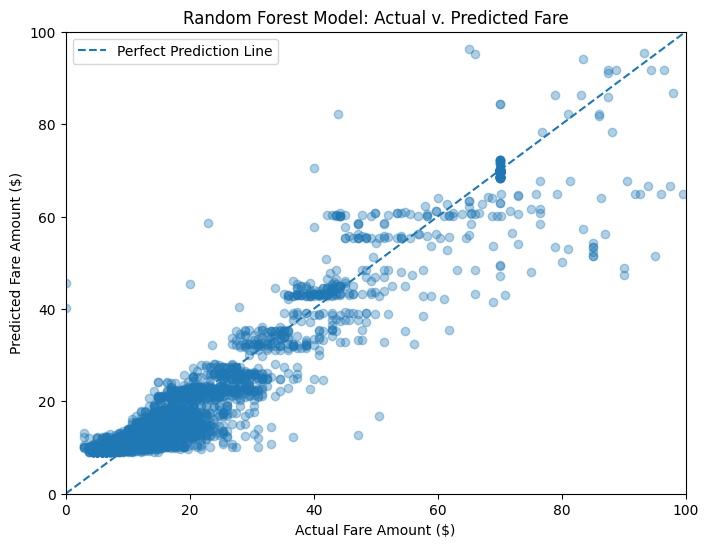

Plot saved locally:  fare_predictions.png
File was uplaoded sucessfuly:  taxi_summary_stats.csv


/home/ec2-user/pyspark-venv/lib64/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


File was uplaoded sucessfuly:  model_importances_of_predictors.csv
File was uplaoded sucessfuly:  fare_predictions.png
Completed everything successfuly!


In [34]:
main()